In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

In [2]:
os.chdir(r"/Users/divyankchauhan/Desktop/Ml/deeplearning/Data_cnn 2")

In [3]:
os.getcwd()

'/Users/divyankchauhan/Desktop/Ml/deeplearning/Data_cnn 2'

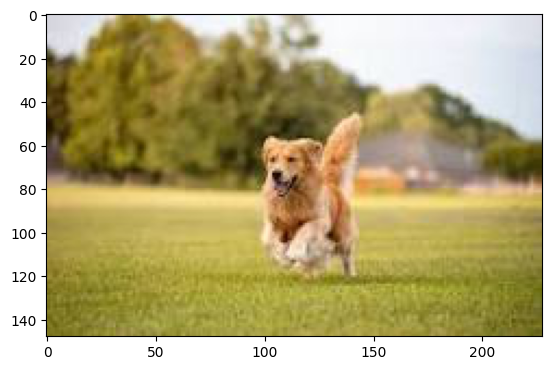

In [4]:
img = image.load_img("training/dog/3.jpeg")
plt.imshow(img)

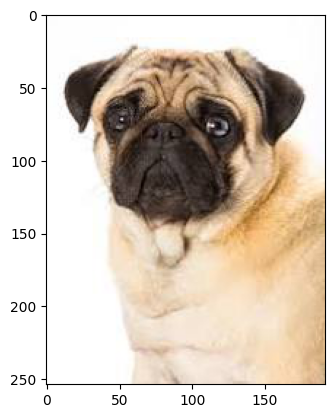

In [5]:
img = image.load_img("testing/1.jpeg")
plt.imshow(img)

In [6]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [7]:
tr_location = r"/Users/divyankchauhan/Desktop/Ml/deeplearning/Data_cnn 2/training"
val_location = r"/Users/divyankchauhan/Desktop/Ml/deeplearning/Data_cnn 2/Validation"

In [8]:
train_data = train.flow_from_directory(tr_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")
valid_data = validation.flow_from_directory(val_location,
                                      target_size=(200,200),
                                      batch_size= 3,
                                      class_mode= "binary")

Found 8 images belonging to 2 classes.
Found 4 images belonging to 2 classes.


In [9]:
train_data.class_indices

{'cat': 0, 'dog': 1}

In [10]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation="relu"),

    tf.keras.layers.Dense(1,activation="sigmoid")])

In [11]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss = "binary_crossentropy", optimizer= RMSprop(learning_rate= 0.001),
             metrics=["accuracy"])

In [13]:
model.fit(train_data,steps_per_epoch=3, epochs= 10 , validation_data=valid_data)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.3208 - loss: 8.9939 - val_accuracy: 0.5000 - val_loss: 0.6833
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6458 - loss: 0.5315 - val_accuracy: 1.0000 - val_loss: 0.3886
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7917 - loss: 1.0593 - val_accuracy: 0.7500 - val_loss: 0.6500
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6500 - loss: 0.4668 - val_accuracy: 1.0000 - val_loss: 0.2428
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.1755 - val_accuracy: 1.0000 - val_loss: 0.1795
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8875 - loss: 0.1061 - val_accuracy: 0.7500 - val_loss: 0.6236
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8125 - loss: 0.1890 - val_accuracy: 0.7500 - val_loss: 0.4613
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.3000 - loss: 1.4668 - val_accuracy: 1.0000 - val_loss: 0.0900

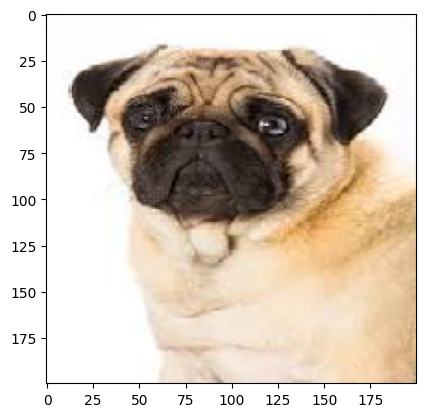

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Dog


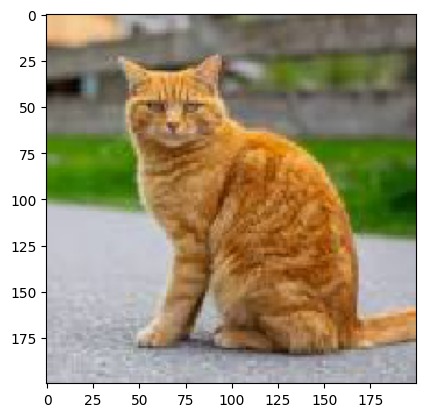

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
cat


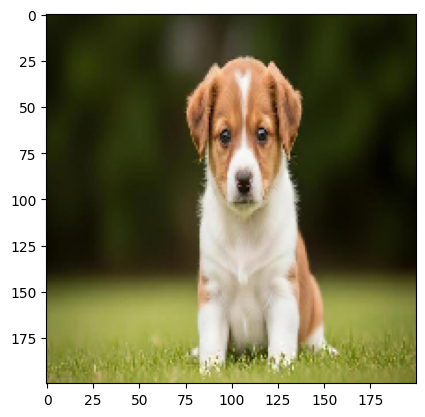

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Dog


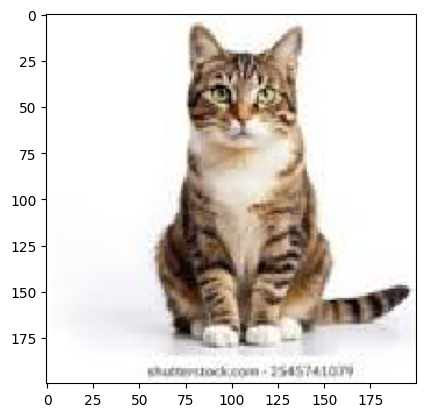

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
cat


In [14]:
path = r"/Users/divyankchauhan/Desktop/Ml/deeplearning/Data_cnn 2/testing"
for i in os.listdir(path):
    img = image.load_img(path+"/"+i,target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    x = image.img_to_array(img)
    x = np.expand_dims(x,axis = 0)
    pic = np.vstack([x])
    val = model.predict(pic)
    if val==0:
        print("cat")
    else:
        print("Dog")